In [10]:
import os
import torch
import cv2
import glob
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
import multiprocessing
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image, ImageDraw, ImageFont

In [ ]:
class SimpleObjectDetectionDataset(CocoDetection):
    """
    Inherits from CocoDetection.
    Returns (image, target) where:
      - image: a PIL image (optionally transformed)
      - target: a dict with keys:
          "boxes": FloatTensor[N, 4] in [x_min, y_min, x_max, y_max] format,
          "labels": Int64Tensor[N] (COCO category ids)
    """
    def __init__(self, root, annFile, transform=None):
        # Pass transforms=None to the parent to prevent it from calling transforms automatically.
        super(SimpleObjectDetectionDataset, self).__init__(root, annFile, transform=None)
        self.custom_transforms = transform  # Our custom transform to apply to the image

    def __getitem__(self, idx):
        print("Entered getitem")
        image_id = self.ids[idx]
        image = self._load_image(image_id)
        annotations = self._load_target(image_id)
        
        # Only pick the first valid annotation (one bounding box and one label)
        box = None
        label = None
        for ann in annotations:
            if "bbox" in ann and isinstance(ann["bbox"], list) and len(ann["bbox"]) == 4:
                x, y, w, h = ann["bbox"]
                # Check for positive width and height
                if w > 0 and h > 0:
                    box = [x, y, x + w, y + h]
                    label = ann["category_id"]
                    break
        # If no valid bbox is found, assign a dummy value
        if box is None:
            box = [0.0, 0.0, 0.0, 0.0]
            label = 0
        
        # Convert to tensors; each sample returns a single box of shape [4] and a scalar label.
        box = torch.tensor(box, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)
        target = {"boxes": box, "labels": label}
        
        if self.custom_transforms is not None:
            image = self.custom_transforms(image)
        return image, target


In [72]:
class SimpleDetectionCNN(nn.Module):
    def __init__(self, num_classes):
        """
        A simple CNN that:
          - Uses several convolutional layers for feature extraction.
          - Has two heads: one for bounding box regression (4 numbers)
            and one for classification (num_classes outputs).
        """
        super(SimpleDetectionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # input: 3 x 224 x 224
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 x 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 x 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 x 28 x 28
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
        )
        # Bounding box regression head: outputs 4 coordinates
        self.bbox_head = nn.Linear(512, 4)
        # Classification head: outputs num_classes scores
        self.class_head = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        bbox = self.bbox_head(x)         # Predicted bounding box coordinates
        class_logits = self.class_head(x)  # Class scores (logits)
        return bbox, class_logits

#############################################
# 3. Training Function
#############################################
def train_model(model, data_loader, optimizer, device, num_epochs=5):
    model.train()
    loss_bbox_fn = nn.L1Loss()            # L1 loss for bounding box regression
    loss_cls_fn = nn.CrossEntropyLoss()   # Cross-entropy for classification
    for epoch in range(num_epochs):
        print(f"Entered Train method: Epoch {epoch+1}")
        running_loss = 0.0
        total_correct = 0
        total_samples = 0
        
        for images, targets in data_loader:
            # Move each image to the device and stack them (assuming they share the same shape)
            images = [img.to(device) for img in images]
            images = torch.stack(images, dim=0)
            
            # Since targets are dictionaries with fixed shapes, stack them
            bbox_targets = torch.stack([t["boxes"] for t in targets]).to(device)   # shape: (batch, 4)
            label_targets = torch.stack([t["labels"] for t in targets]).to(device)  # shape: (batch,)
            
            optimizer.zero_grad()
            # Forward pass: our model outputs predicted bounding boxes and class logits
            pred_bbox, pred_logits = model(images)
            
            # Compute losses
            loss_bbox = loss_bbox_fn(pred_bbox, bbox_targets)
            loss_cls = loss_cls_fn(pred_logits, label_targets)
            loss = loss_bbox + loss_cls
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
            # Calculate classification accuracy
            _, predicted = torch.max(pred_logits, 1)
            total_correct += (predicted == label_targets).sum().item()
            total_samples += label_targets.size(0)
            
        epoch_loss = running_loss / len(data_loader.dataset)
        accuracy = (total_correct / total_samples) * 100.0
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%")
    print("Finished Training")
    

#############################################
# 4. Inference and Visualization Function
#############################################
def predict_and_draw(model, image_path, device, transform):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    orig_image = image.copy()
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_bbox, pred_logits = model(image_tensor)
    
    # Get predicted class index from logits
    pred_class = torch.argmax(pred_logits, dim=1).item()
    # Get predicted bounding box (as numpy array)
    bbox = pred_bbox[0].cpu().numpy()
    
    # Draw the predicted bounding box on the image
    draw = ImageDraw.Draw(orig_image)
    x1, y1, x2, y2 = bbox
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
    draw.text((x1, y1), f"Class: {pred_class}", fill="red")
    
    plt.figure(figsize=(8, 6))
    plt.imshow(np.array(orig_image))
    plt.axis("off")
    plt.show()
    
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets



In [73]:
if __name__ == "__main__":
    # Paths for the dataset (update these paths accordingly)
    # For example, using the "mmsample" Kaggle dataset structure:
    dataset_root = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017"
    annFile = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json"
    
    # Define transforms (resize images to 224x224 and convert to tensor)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    print("Creating dataset and data loader...")
    # Create the dataset and data loader
    dataset = SimpleObjectDetectionDataset(dataset_root, annFile, transform=transform)
    data_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate_fn)
    
    # Set number of classes (for COCO, there are 91 classes including background)
    num_classes = 91
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = SimpleDetectionCNN(num_classes).to(device)
    
    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    print("Training the model...")
    # Train the model
    train_model(model, data_loader, optimizer, device, num_epochs=1)

Creating dataset and data loader...
loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
Training the model...
Entered Train method: Epoch 1
Epoch 1/1, Loss: 122.6180, Accuracy: 10.06%
Finished Training


In [78]:
# Save the trained model
torch.save(model.state_dict(), "custom_detection_model.pth")
print("Model saved as custom_detection_model.pth")

Model saved as custom_detection_model.pth


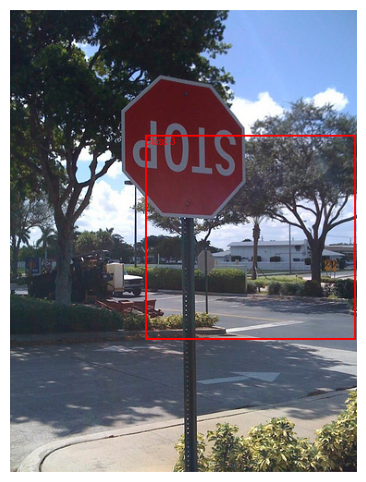

In [79]:
# Run inference on a test image
test_image_path = "test3.jpg"  # update with your test image path
predict_and_draw(model, test_image_path, device, transform)

In [88]:
import os
import torch
import cv2
import glob
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
import multiprocessing
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#############################################
# 1. Updated Dataset for Multiple Object Detection
#############################################
class SimpleObjectDetectionDataset(CocoDetection):
    """
    Inherits from CocoDetection.
    Returns (image, target) where:
      - image: a PIL image (optionally transformed)
      - target: a dict with keys:
            "boxes": FloatTensor of shape [max_objects, 4] in [x_min, y_min, x_max, y_max] format,
            "labels": Int64Tensor of shape [max_objects] (COCO category ids, with 0 for padded objects)
    We gather all valid annotations for an image and pad/truncate to a fixed number (max_objects).
    """
    def __init__(self, root, annFile, transform=None, max_objects=10):
        # Initialize parent without automatic transforms
        super(SimpleObjectDetectionDataset, self).__init__(root, annFile, transforms=None)
        self.custom_transforms = transform  # Custom image transform
        # Ensure image IDs are available
        self.ids = list(sorted(self.coco.getImgIds()))
        self.max_objects = max_objects

    def _load_image(self, image_id):
        # Use the COCO API's loadImgs to get image info
        info = self.coco.loadImgs(image_id)[0]
        file_name = info['file_name']
        image_path = os.path.join(self.root, file_name)
        return Image.open(image_path).convert("RGB")
    
    def __getitem__(self, idx):
        image_id = self.ids[idx]
        image = self._load_image(image_id)
        annotations = self._load_target(image_id)
        
        boxes_list = []
        labels_list = []
        # Gather all valid annotations
        for ann in annotations:
            if "bbox" in ann and isinstance(ann["bbox"], list) and len(ann["bbox"]) == 4:
                x, y, w, h = ann["bbox"]
                if w > 0 and h > 0:
                    boxes_list.append([x, y, x + w, y + h])
                    labels_list.append(ann["category_id"])
        
        # Convert lists to tensors
        # If there are fewer than max_objects, pad with zeros (and label 0 for dummy)
        if len(boxes_list) < self.max_objects:
            pad_num = self.max_objects - len(boxes_list)
            boxes_list.extend([[0.0, 0.0, 0.0, 0.0]] * pad_num)
            labels_list.extend([0] * pad_num)
        # If there are more, truncate to max_objects
        if len(boxes_list) > self.max_objects:
            boxes_list = boxes_list[:self.max_objects]
            labels_list = labels_list[:self.max_objects]
            
        boxes = torch.tensor(boxes_list, dtype=torch.float32)  # Shape: [max_objects, 4]
        labels = torch.tensor(labels_list, dtype=torch.long)   # Shape: [max_objects]
        target = {"boxes": boxes, "labels": labels}
        
        if self.custom_transforms is not None:
            image = self.custom_transforms(image)
        return image, target

#############################################
# 2. Updated Model for Multiple Object Detection
#############################################
class SimpleDetectionCNN(nn.Module):
    def __init__(self, num_classes, max_objects=10):
        """
        A simple CNN for object detection that predicts multiple objects per image.
        It has two heads:
          - bbox_head: outputs max_objects * 4 numbers (reshaped to [batch, max_objects, 4])
          - class_head: outputs max_objects * num_classes numbers (reshaped to [batch, max_objects, num_classes])
        """
        super(SimpleDetectionCNN, self).__init__()
        self.max_objects = max_objects
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Input: 3 x 224 x 224
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 16 x 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 32 x 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)   # -> 64 x 28 x 28
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
        )
        # Bounding box regression head: outputs max_objects * 4 numbers
        self.bbox_head = nn.Linear(512, max_objects * 4)
        # Classification head: outputs max_objects * num_classes numbers
        self.class_head = nn.Linear(512, max_objects * num_classes)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.features(x)
        x = x.view(batch_size, -1)
        x = self.fc(x)
        # Get raw outputs; then reshape for multiple detections per image
        bbox_out = self.bbox_head(x)  # Shape: (batch, max_objects * 4)
        class_out = self.class_head(x)  # Shape: (batch, max_objects * num_classes)
        # Reshape outputs
        bbox_out = bbox_out.view(batch_size, self.max_objects, 4)
        class_out = class_out.view(batch_size, self.max_objects, -1)
        return bbox_out, class_out

#############################################
# 3. Updated Training Function for Multiple Objects
#############################################
def train_model(model, data_loader, optimizer, device, num_epochs=5):
    model.train()
    # We'll compute L1 loss for bounding boxes and CrossEntropy loss for classification.
    # For classification, we ignore padded objects (label 0).
    loss_bbox_fn = nn.L1Loss()            
    loss_cls_fn = nn.CrossEntropyLoss(ignore_index=0)  # ignore background/dummy class
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs} - Training")
        running_loss = 0.0
        total_correct = 0
        total_samples = 0
        
        for images, targets in data_loader:
            # Move each image to the device and stack them (all images share same shape)
            images = [img.to(device) for img in images]
            images = torch.stack(images, dim=0)
            
            # Targets: each is a dict with "boxes" ([max_objects, 4]) and "labels" ([max_objects])
            bbox_targets = torch.stack([t["boxes"] for t in targets]).to(device)   # (batch, max_objects, 4)
            label_targets = torch.stack([t["labels"] for t in targets]).to(device)  # (batch, max_objects)
            
            optimizer.zero_grad()
            pred_bbox, pred_logits = model(images)  # pred_bbox: (batch, max_objects, 4), pred_logits: (batch, max_objects, num_classes)
            
            # Compute bbox loss over all objects (dummy ones are zeros; loss will be near zero if prediction is also zero)
            loss_bbox = loss_bbox_fn(pred_bbox, bbox_targets)
            
            # For classification, we need to compute loss over each object.
            # Reshape predictions and labels to (batch*max_objects, num_classes) and (batch*max_objects)
            pred_logits_flat = pred_logits.view(-1, pred_logits.size(-1))
            label_targets_flat = label_targets.view(-1)
            loss_cls = loss_cls_fn(pred_logits_flat, label_targets_flat)
            
            loss = loss_bbox + loss_cls
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
            # For accuracy, compare predicted labels for non-dummy objects (label != 0)
            _, predicted = torch.max(pred_logits, 2)  # shape: (batch, max_objects)
            # Create a mask for valid objects (label_targets != 0)
            valid_mask = label_targets != 0
            total_correct += ((predicted == label_targets) & valid_mask).sum().item()
            total_samples += valid_mask.sum().item()
            
        epoch_loss = running_loss / len(data_loader.dataset)
        accuracy = (total_correct / total_samples) * 100.0 if total_samples > 0 else 0.0
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%")
    print("Finished Training")

#############################################
# 4. Updated Inference and Visualization Function
#############################################
def predict_and_draw(model, image_path, device, transform, max_objects=10):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    orig_image = image.copy()
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_bbox, pred_logits = model(image_tensor)
    # pred_bbox: (1, max_objects, 4), pred_logits: (1, max_objects, num_classes)
    pred_logits = pred_logits[0]  # shape: (max_objects, num_classes)
    pred_bbox = pred_bbox[0]      # shape: (max_objects, 4)
    # Get predicted class indices for each object
    _, pred_classes = torch.max(pred_logits, 1)
    pred_bbox = pred_bbox.cpu().numpy()
    pred_classes = pred_classes.cpu().numpy()
    
    draw = ImageDraw.Draw(orig_image)
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except IOError:
        font = ImageFont.load_default()
    
    for i in range(max_objects):
        # Skip dummy predictions (class 0)
        if pred_classes[i] == 0:
            continue
        # Get raw bbox coordinates
        x1, y1, x2, y2 = pred_bbox[i]
        # Ensure coordinates are in the correct order
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        # Draw the bounding box and label
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        # draw.text((x1, y1), f"Class: {pred_classes[i]}", fill="red", font=font)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(np.array(orig_image))
    plt.axis("off")
    plt.show()

#############################################
# 5. Collate Function for DataLoader
#############################################
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets


In [97]:
if __name__ == "__main__":
    # Paths for the dataset (update these paths accordingly)
    dataset_root = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017"
    annFile = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json"
    
    # Define transforms: resize to 224x224 and convert to tensor.
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    print("Creating dataset and data loader...")
    # Create dataset and data loader using our custom collate function
    dataset = SimpleObjectDetectionDataset(dataset_root, annFile, transform=transform, max_objects=10)
    data_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate_fn)
    
    # Set number of classes (for COCO, 91 including background/dummy)
    num_classes = 91
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = SimpleDetectionCNN(num_classes, max_objects=10).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-5)
    print("Training the model...")
    # Train the model
    train_model(model, data_loader, optimizer, device, num_epochs=10)
    
    torch.save(model.state_dict(), "custom_detection_model.pth")
    print("Model saved as custom_detection_model.pth")

Creating dataset and data loader...
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
Training the model...
Epoch 1/10 - Training
Epoch 1/10, Loss: 134.4747, Accuracy: 29.78%
Epoch 2/10 - Training
Epoch 2/10, Loss: 117.2808, Accuracy: 30.30%
Epoch 3/10 - Training
Epoch 3/10, Loss: 116.1362, Accuracy: 30.55%
Epoch 4/10 - Training
Epoch 4/10, Loss: 115.8505, Accuracy: 31.14%
Epoch 5/10 - Training
Epoch 5/10, Loss: 115.6407, Accuracy: 31.95%
Epoch 6/10 - Training
Epoch 6/10, Loss: 115.4481, Accuracy: 33.04%
Epoch 7/10 - Training
Epoch 7/10, Loss: 115.2613, Accuracy: 33.96%
Epoch 8/10 - Training
Epoch 8/10, Loss: 115.0829, Accuracy: 35.46%
Epoch 9/10 - Training
Epoch 9/10, Loss: 114.9420, Accuracy: 36.81%
Epoch 10/10 - Training
Epoch 10/10, Loss: 114.6934, Accuracy: 38.34%
Finished Training
Model saved as custom_detection_model.pth


In [98]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
test_model = SimpleDetectionCNN(91, max_objects=5).to(device)

model.load_state_dict(torch.load("custom_detection_model.pth", map_location=device))
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


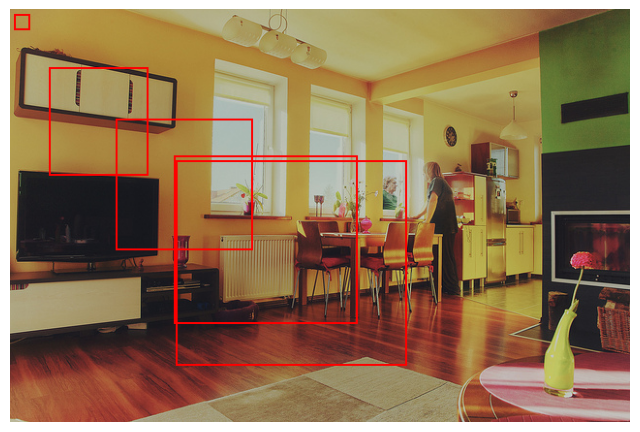

In [102]:
test_image_path = "test2.jpg"  # Update this path as necessary
predict_and_draw(model, test_image_path, device, transform, max_objects=5)

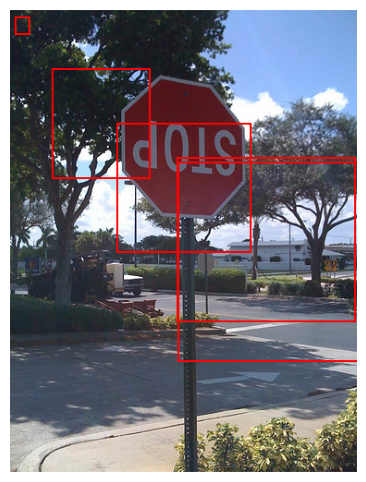

In [101]:
test_image_path = "test3.jpg"  # Update this path as necessary
predict_and_draw(model, test_image_path, device, transform, max_objects=5)

In [31]:
import numpy as np
import os
import torchvision.transforms.functional as TF
import json
from tqdm import tqdm 
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor, ZoeDepthForDepthEstimation

{'license': 4, 'file_name': '000000342932.jpg', 'coco_url': 'http://images.cocodataset.org/train2017/000000342932.jpg', 'height': 480, 'width': 640, 'date_captured': '2013-11-16 18:11:06', 'flickr_url': 'http://farm7.staticflickr.com/6031/6380690371_0746e29fa5_z.jpg', 'id': 342932}
342932


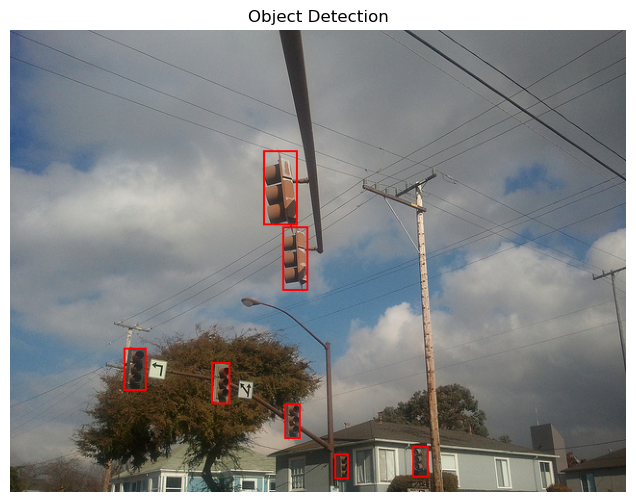

In [7]:
# Path to COCO dataset
COCO_PATH = "/kaggle/input/mmsample"

# Load COCO annotations
def load_coco_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        annotations = json.load(f)
    return annotations

# Load COCO train annotations
train_annotation_path = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json"
coco_train_annotations = load_coco_annotations(train_annotation_path)

# Get image ID and bounding boxes
def get_image_annotations(image_id, annotations):
    image_data = None
    for img in annotations["images"]:
        if img["id"] == image_id:
            image_data = img
            break

    if image_data is None:
        return None, None

    bboxes = []
    labels = []
    for ann in annotations["annotations"]:
        if ann["image_id"] == image_id:
            x, y, w, h = ann["bbox"]
            bboxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

    return image_data, bboxes, labels

# Select a random image from the annotation (instead of always the first)
all_images = coco_train_annotations["images"]
random_image = random.choice(all_images)
image_id = random_image["id"]
print(random_image)
print(image_id)

# Retrieve bounding boxes + labels for this image
image_data, bboxes, labels = get_image_annotations(image_id, coco_train_annotations)

if image_data is None:
    print("No image found with this ID.")
else:
    # Load the actual image from 'train2017' folder
    image_path = os.path.join("/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017", image_data["file_name"])
    image = Image.open(image_path).convert("RGB")

    # Draw bounding boxes
    draw = ImageDraw.Draw(image)
    for box in bboxes:
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

    # Display image with bounding boxes
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Object Detection")
    plt.show()

In [8]:
# Root folder on Kaggle for your dataset
COCO_PATH = "/kaggle/input/mmsample"

# Paths to the annotations
train_annotation_path = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json"
val_annotation_path   = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_val2017.json"

# Path to the train images
train_image_dir = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017"

print("Train annotation file:", train_annotation_path)
print("Val annotation file:", val_annotation_path)
print("Train images folder:", train_image_dir)

Train annotation file: /Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json
Val annotation file: /Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_val2017.json
Train images folder: /Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017


In [9]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = CocoDetection(
    root=train_image_dir,
    annFile=train_annotation_path,
    transform=transform
)

loading annotations into memory...
Done (t=0.38s)
creating index...
index created!


In [14]:
COCO_PATH = "/kaggle/input/mmsample"

# Images and Annotations
image_dir = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/train2017"  # e.g., /kaggle/input/mmsample/train2017
annotation_file = "/Users/shivansh052k/Documents/UB/Academics/Semester_2/CV & IP/Project/Dataset/archive/annotations/instances_train2017.json"

all_image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
n_images = len(all_image_files)
print("Total images found:", n_images)

# If dataset is very small, skip splitting
if n_images < 2:
    train_imgs = all_image_files
    val_imgs = []
else:
    train_imgs, val_imgs = train_test_split(all_image_files, test_size=0.1, random_state=42)

print(f"Train images: {len(train_imgs)}, Validation images: {len(val_imgs)}")

# Single-Object Dataset with cat2idx Mapping

class CoCoSingleObjectDataset(Dataset):
    """
    A wrapper around torchvision.datasets.CocoDetection that:
      - Resizes images to a fixed size (e.g., 128x128)
      - Scales bounding boxes accordingly
      - Uses only the first annotation per image (for a single-object detection model)
      - Maps COCO category_id to a contiguous range [0..79] with cat2idx
    """
    def __init__(self, image_paths, annFile, transform=None, input_size=128):
        """
        image_paths: list of image file paths (train or val split)
        annFile: path to instances_train2017.json
        transform: resize, toTensor, etc.
        input_size: assumed final image size for bounding box scaling
        """
        super().__init__()
        self.image_paths = image_paths
        self.transform = transform
        self.input_size = input_size
        
        # Use CocoDetection to parse JSON annotations
        self.coco_dataset = CocoDetection(
            root=os.path.dirname(image_paths[0]) if image_paths else image_dir,  
            annFile=annFile,
            transform=None  # We'll apply transform manually
        )

        # Build a file_name -> image_id map
        self.file_to_id = {}
        for img_info in self.coco_dataset.coco.imgs.values():
            self.file_to_id[img_info["file_name"]] = img_info["id"]

        # Build category ID -> index mapping (cat2idx)
        cat_ids = sorted(self.coco_dataset.coco.getCatIds())
        self.cat2idx = {cat_id: idx for idx, cat_id in enumerate(cat_ids)}

        print("Number of unique category IDs in dataset:", len(cat_ids))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if idx >= len(self.image_paths):
            raise IndexError("Index out of range for dataset.")

        img_path = self.image_paths[idx]
        file_name = os.path.basename(img_path)

        # If the file_name not in self.file_to_id, we have no annotation => dummy
        if file_name not in self.file_to_id:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.zeros((1,4)), torch.zeros((1,), dtype=torch.long)

        image_id = self.file_to_id[file_name]
        ann_list = self.coco_dataset.coco.loadAnns(
            self.coco_dataset.coco.getAnnIds(imgIds=image_id)
        )
        image = Image.open(img_path).convert("RGB")

        # If no annotation, return dummy
        if len(ann_list) == 0:
            if self.transform:
                image = self.transform(image)
            return image, torch.zeros((1,4)), torch.zeros((1,), dtype=torch.long)

        # Take the first annotation
        ann = ann_list[0]
        bbox = ann["bbox"]  # [x, y, w, h] in original coordinates
        cat_id = ann["category_id"]
        
        # Map cat_id to a 0-based index
        if cat_id not in self.cat2idx:
            # If we find a cat_id not in cat2idx, treat as background or clamp
            cat_idx = 0
        else:
            cat_idx = self.cat2idx[cat_id]
        
        # Manually transform the image (resize to input_size x input_size)
        orig_w, orig_h = image.size
        if self.transform:
            image = self.transform(image)
            new_w, new_h = self.input_size, self.input_size
            scale_w = new_w / orig_w
            scale_h = new_h / orig_h
            x1 = bbox[0] * scale_w
            y1 = bbox[1] * scale_h
            x2 = (bbox[0] + bbox[2]) * scale_w
            y2 = (bbox[1] + bbox[3]) * scale_h
        else:
            x1, y1 = bbox[0], bbox[1]
            x2, y2 = bbox[0] + bbox[2], bbox[1] + bbox[3]

        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        labels = torch.tensor([cat_idx], dtype=torch.long)

        return image, boxes, labels

# Build Train/Val Datasets & Loaders
from torch.utils.data import DataLoader

input_size = 128
transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor()
])

train_dataset = CoCoSingleObjectDataset(
    image_paths=train_imgs,
    annFile=annotation_file,
    transform=transform,
    input_size=input_size
)

val_dataset = CoCoSingleObjectDataset(
    image_paths=val_imgs,
    annFile=annotation_file,
    transform=transform,
    input_size=input_size
)

def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images, 0)
    return images, list(boxes), list(labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))        

Total images found: 5000
Train images: 4500, Validation images: 500
loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
Number of unique category IDs in dataset: 80
loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Number of unique category IDs in dataset: 80
Train dataset size: 4500
Val dataset size: 500


In [ ]:
class CustomObjectDetectorCNN(nn.Module):
    def __init__(self, num_classes, input_size=256):
        super(CustomObjectDetectorCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        final_spatial = input_size // 8  # e.g. 128/8=16
        self.fc1 = nn.Linear(128 * final_spatial * final_spatial, 1024)
        self.fc2 = nn.Linear(1024, 512)

        self.bbox_head = nn.Linear(512, 4)  # (x, y, w, h)
        self.class_head = nn.Linear(512, num_classes + 1)  # +1 for background

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        bbox = self.bbox_head(x)
        class_logits = self.class_head(x)
        return bbox, class_logits

In [37]:
# Example training routine
def train_model(train_loader, num_classes, input_size=128, num_epochs=10, save_path="custom_detector.pth"):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Initialize the model, loss functions, and optimizer
    model = CustomObjectDetectorCNN(num_classes=num_classes, input_size=input_size).to(device)
    bbox_loss_fn = nn.MSELoss()
    class_loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        # Wrap the DataLoader with tqdm for a progress bar
        for images, boxes_list, labels_list in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            
            # Build targets (using only the first object per image)
            batch_bbox_targets = []
            batch_class_targets = []
            for bxs, lbls in zip(boxes_list, labels_list):
                if len(bxs) > 0:
                    # Use the first object's bbox and label.
                    box = bxs[0]  # [x1, y1, x2, y2] in pixel coordinates
                    # Normalize bounding box coordinates relative to input_size (here 128)
                    w = (box[2] - box[0]) / input_size
                    h = (box[3] - box[1]) / input_size
                    x = box[0] / input_size
                    y = box[1] / input_size
                    norm_box = torch.tensor([x, y, w, h], dtype=torch.float32)
                    batch_bbox_targets.append(norm_box)
                    batch_class_targets.append(lbls[0])
                else:
                    # If no object is present, assume background (class index 0)
                    batch_bbox_targets.append(torch.zeros(4))
                    batch_class_targets.append(torch.tensor(0))

            batch_bbox_targets = torch.stack(batch_bbox_targets).to(device)
            batch_class_targets = torch.stack(batch_class_targets).to(device).long()

            optimizer.zero_grad()
            pred_bboxes, pred_classes = model(images)

            loss_bbox = bbox_loss_fn(pred_bboxes, batch_bbox_targets)
            loss_class = class_loss_fn(pred_classes, batch_class_targets)
            loss = loss_bbox + loss_class

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            
            # Compute accuracy (for classification)
            pred_labels = torch.argmax(pred_classes, dim=1)
            total_correct += (pred_labels == batch_class_targets).sum().item()
            total_samples += batch_class_targets.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = 100.0 * total_correct / total_samples if total_samples > 0 else 0
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    # Save the trained model weights
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

    return model

In [ ]:
trained_model = train_model(train_loader, num_classes=91, input_size=128, num_epochs=15, save_path="custom_detector.pth")

Epoch 1/15: 100%|██████████| 563/563 [01:11<00:00,  7.82it/s]


Epoch 1/15, Loss: 3.8018, Accuracy: 19.51%


Epoch 2/15: 100%|██████████| 563/563 [01:40<00:00,  5.58it/s]


Epoch 2/15, Loss: 3.6179, Accuracy: 19.38%


Epoch 3/15: 100%|██████████| 563/563 [01:23<00:00,  6.71it/s]


...

Epoch 13/15, Loss: 0.1903, Accuracy: 97.82%


Epoch 14/15: 100%|██████████| 563/563 [01:50<00:00,  5.08it/s]


Epoch 14/15, Loss: 0.1232, Accuracy: 99.07%


Epoch 15/15: 100%|██████████| 563/563 [01:52<00:00,  5.02it/s]


Epoch 15/15, Loss: 0.0971, Accuracy: 99.42%
Model saved to custom_detector.pth


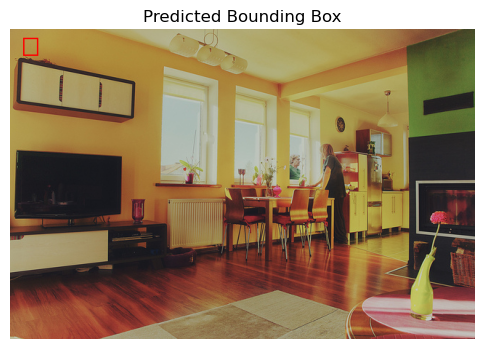

In [54]:
test_model = CustomObjectDetectorCNN(num_classes=91, input_size=128)
test_model.load_state_dict(torch.load("custom_detector.pth"))
test_model.eval()

# 2) Transform your test image EXACTLY as in training
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# 3) Load and transform the test image
image = Image.open("test2.jpg").convert("RGB")
image_tensor = transform(image).unsqueeze(0)

# 4) Run inference
with torch.no_grad():
    pred_bboxes, pred_classes = test_model(image_tensor)

# 5) Convert normalized coords -> pixel coords
# For the first bounding box (assuming single-object approach)
pred_box = pred_bboxes[0].cpu().numpy()  # [x, y, w, h] in [0..1]
x, y, w, h = pred_box
x1 = x * 128
y1 = y * 128
x2 = x1 + (w * 128)
y2 = y1 + (h * 128)

# 6) Draw the box on the original (untransformed) image
vis_image = image.copy()
draw = ImageDraw.Draw(vis_image)
draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

plt.figure(figsize=(6,6))
plt.imshow(vis_image)
plt.axis("off")
plt.title("Predicted Bounding Box")
plt.show()

Predicted BBox coords (pixel): 94 72 120 123
Predicted Class Index: 23


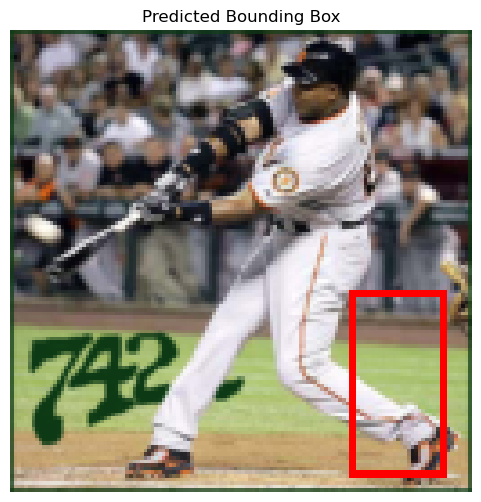

In [49]:
trained_model.eval()

# Suppose val_dataset returns (image_tensor, gt_boxes, gt_labels)
test_image, gt_boxes, gt_labels = val_dataset[22]  # e.g., sample #19
input_tensor = test_image.unsqueeze(0).to(device)  # shape (1,3,128,128)

with torch.no_grad():
    pred_bbox, pred_class_logits = trained_model(input_tensor)

# Convert from shape (1,4) to shape (4,)
pred_bbox = pred_bbox.squeeze(0).cpu().numpy()  # normalized [x, y, w, h] in [0,1]
pred_class_idx = torch.argmax(pred_class_logits, dim=1).item()

# Convert normalized bounding box to pixel coordinates
input_size = 128  # The image is 128x128 in your training pipeline
x, y, w, h = pred_bbox  # normalized
x1 = int(x * input_size)
y1 = int(y * input_size)
x2 = int((x + w) * input_size)
y2 = int((y + h) * input_size)

print("Predicted BBox coords (pixel):", x1, y1, x2, y2)
print("Predicted Class Index:", pred_class_idx)

# Convert test_image tensor to PIL
vis_image = TF.to_pil_image(test_image.cpu())

# Draw bounding box
draw = ImageDraw.Draw(vis_image)
draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
# draw.text((x1, y1), f"Class: {pred_class_idx}", fill="yellow")

plt.figure(figsize=(6,6))
plt.imshow(vis_image)
plt.axis("off")
plt.title("Predicted Bounding Box")
plt.show()


In [47]:
# 'vis_image' is a PIL image of shape 128x128
object_crop = vis_image.crop((x1, y1, x2, y2))
object_crop.show() 